# Binary Classification for SOH and RUL (2 classes)
We train **leakage-safe binary classification** models for:
- **SOH** (State of Health)
- **RUL** (Remaining Useful Life)

## What we do in this notebook
- Load `processed_data/feature_aggregation.csv` (engineered features + targets + `battery_id`)
- Use feature lists when available:
  - `processed_data/selected_features_soh.csv` for SOH
  - `processed_data/selected_features_rul.csv` for RUL
  - For each list, we report requested / found / missing features and fall back to numeric features if nothing matches
- Build **binary targets**:
  - **SOH**: configurable scheme (`healthy_vs_rest` or `eol_vs_rest`)
  - **RUL**: **Short vs Not-Short** using a **training-only** threshold ($q_{1/3}$)
- Split data **by battery_id** so the same battery never appears in both train and test
- Train and compare two model families: Logistic Regression (linear baseline) and Random Forest (nonlinear)
- Evaluate with accuracy, balanced accuracy, macro-F1, ROC AUC (SOH), confusion matrices, and train→test gap tables

In [54]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    GroupKFold,
 )
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
 )

pd.set_option("display.max_columns", 200)

## 1) Load data
We load the aggregated feature table and construct the modeling matrix `X`.
- If `selected_features_soh.csv` exists and contains a `feature` column, we select those columns and report how many are found.
- If no selected features match, we fall back to all numeric columns except identifiers and target columns.
- We replace inf values and fill missing values using the median (per feature).

In [55]:
from pathlib import Path
# -------------------- PATHS --------------------
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "processed_data" / "feature_aggregation.csv"
OUT_DIR = PROJECT_ROOT / "processed_data"
SELECTED_FEATURES_PATH = OUT_DIR / "selected_features_soh.csv"

# -------------------- LOAD --------------------
df = pd.read_csv(DATA_PATH)
required_cols = {"battery_id", "SOH"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in feature_aggregation.csv: {missing}")

# Optional: selected features list (preferred)
feature_names = None
if SELECTED_FEATURES_PATH.exists():
    sel = pd.read_csv(SELECTED_FEATURES_PATH)
    if "feature" in sel.columns:
        requested = sel["feature"].astype(str).tolist()
        found = [f for f in requested if f in df.columns]
        missing_feats = sorted(set(requested) - set(found))
        feature_names = found

        print(f"Selected SOH features file: {SELECTED_FEATURES_PATH.name}")
        print(f"- Requested: {len(requested)}")
        print(f"- Found in dataset: {len(found)}")
        print(f"- Missing from dataset: {len(missing_feats)}")
        if len(missing_feats) and len(missing_feats) <= 15:
            print("  Missing examples:", missing_feats)
        if len(found) == 0:
            print("No selected SOH features matched columns; falling back to numeric feature selection.")
            feature_names = None
    else:
        print(f"{SELECTED_FEATURES_PATH.name} found but no 'feature' column; falling back to all numeric features.")

# Build X
if feature_names:
    X = df[feature_names].copy()
else:
    drop_cols = {"SOH", "SOH_class", "SOH_bin"} | {
        c for c in df.columns if c.lower().endswith("id") or c.lower() in {"battery_id"}
    }
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    use_cols = [c for c in numeric_cols if c not in drop_cols]
    X = df[use_cols].copy()
    print(f"Using {len(use_cols)} numeric feature columns (fallback mode)")

# Basic cleaning
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print("X shape:", X.shape)
print("Batteries:", df["battery_id"].nunique())


Selected SOH features file: selected_features_soh.csv
- Requested: 25
- Found in dataset: 25
- Missing from dataset: 0
X shape: (2247, 25)
Batteries: 24


## 2) Define the 2-class SOH target
Choose one of the following schemes:
- **`healthy_vs_rest`**: label 1 = Healthy ($\mathrm{SOH} \ge 0.80$), label 0 = Not-Healthy ($\mathrm{SOH} < 0.80$)
- **`eol_vs_rest`**: label 1 = End-of-life ($\mathrm{SOH} < 0.60$), label 0 = Not-EOL ($\mathrm{SOH} \ge 0.60$)

In [56]:
BINARY_SCHEME = "healthy_vs_rest"  # change to: "eol_vs_rest"

def soh_to_binary(soh: float, scheme: str) -> int:
    if scheme == "healthy_vs_rest":
        return 1 if soh >= 0.80 else 0
    if scheme == "eol_vs_rest":
        return 1 if soh < 0.60 else 0
    raise ValueError(f"Unknown scheme: {scheme}")

if BINARY_SCHEME == "healthy_vs_rest":
    CLASS_NAMES = ["Not-Healthy", "Healthy"]
    POS_LABEL_MEANING = "Healthy (SOH ≥ 0.80)"
elif BINARY_SCHEME == "eol_vs_rest":
    CLASS_NAMES = ["Not-EOL", "End-of-life"]
    POS_LABEL_MEANING = "End-of-life (SOH < 0.60)"
else:
    raise ValueError(f"Unknown scheme: {BINARY_SCHEME}")

y = df["SOH"].astype(float).apply(lambda s: soh_to_binary(s, BINARY_SCHEME)).astype(int)
df["SOH_bin"] = y

print("Scheme:", BINARY_SCHEME)
print("Positive class (label=1):", POS_LABEL_MEANING)
print("Class distribution (0/1):")
display(y.value_counts().sort_index())

Scheme: healthy_vs_rest
Positive class (label=1): Healthy (SOH ≥ 0.80)
Class distribution (0/1):


SOH
0     546
1    1701
Name: count, dtype: int64

## 3) Battery-level train/test split
We split on **battery_id** to avoid leakage (cycles from the same battery are correlated).

In [57]:
unique_batts = df["battery_id"].unique()
train_batts, test_batts = train_test_split(unique_batts, test_size=0.2, random_state=42)

train_mask = df["battery_id"].isin(train_batts)
test_mask = ~train_mask

X_train = X.loc[train_mask].reset_index(drop=True)
X_test  = X.loc[test_mask].reset_index(drop=True)
y_train = y.loc[train_mask].reset_index(drop=True)
y_test  = y.loc[test_mask].reset_index(drop=True)

print("Train samples:", len(y_train), "| positives:", int(y_train.sum()), "| negatives:", int((1 - y_train).sum()))
print("Test  samples:", len(y_test),  "| positives:", int(y_test.sum()),  "| negatives:", int((1 - y_test).sum()))

Train samples: 1720 | positives: 1371 | negatives: 349
Test  samples: 527 | positives: 330 | negatives: 197


## 4) Train binary classifiers (Logistic Regression + Random Forest)
Why these two models:
- **Logistic Regression** is a strong baseline and often generalizes well (low overfitting risk)
- **Random Forest** captures nonlinearities and interactions without feature scaling
- Both support `predict_proba`, so we can compute ROC AUC and compare ROC curves

In [58]:
models = {
    # Linear baseline (scaled)
    "LogisticRegression (scaled)": Pipeline(steps=[
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42,
            C=1.0,
        )),
    ]),

    # Tree ensemble (regularized to reduce overfitting)
    "RandomForestClassifier (regularized)": RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = {
        "model": model,
        "y_train_pred": model.predict(X_train),
        "y_test_pred": model.predict(X_test),
        "y_test_proba": model.predict_proba(X_test)[:, 1],
    }

## 4a) Tune Logistic Regression (reduce overfitting)
We tune Logistic Regression **only on the training split** using **GroupKFold by `battery_id`** (still preventing leakage across batteries).
This typically reduces the train→test gap by controlling regularization strength (`C`) and penalty type (`l1` vs `l2`).

In [59]:
# GroupKFold tuning on TRAIN only (groups = battery_id)
groups_train = df.loc[train_mask, "battery_id"].to_numpy()
n_splits = min(5, len(np.unique(groups_train)))
gkf = GroupKFold(n_splits=n_splits)

logreg_pipe = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42,
    )),
 ])

param_grid = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
}

search = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=gkf,
    n_jobs=-1,
    refit=True,
)

search.fit(X_train, y_train, groups=groups_train)

print("LogReg tuning (GroupKFold on train)")
print("n_splits:", n_splits)
print("Best CV macro-F1:", round(float(search.best_score_), 4))
print("Best params:", search.best_params_)

# Replace baseline Logistic Regression with tuned version, then refit all models for downstream cells
models = {
    "LogisticRegression (tuned, group-CV)": search.best_estimator_,
    "RandomForestClassifier (regularized)": models["RandomForestClassifier (regularized)"],
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = {
        "model": model,
        "y_train_pred": model.predict(X_train),
        "y_test_pred": model.predict(X_test),
        "y_test_proba": model.predict_proba(X_test)[:, 1],
    }

LogReg tuning (GroupKFold on train)
n_splits: 5
Best CV macro-F1: 0.9463
Best params: {'clf__C': 0.1, 'clf__penalty': 'l1'}


## 4b) Tune Random Forest (reduce overfitting)
We tune the Random Forest **only on the training split** using the same **GroupKFold by `battery_id`**.
This targets better generalization by searching over regularization-related parameters like `max_depth`, `min_samples_leaf`, etc.

In [60]:
# Random Forest tuning on TRAIN only (GroupKFold by battery_id)
tuned_logreg = models["LogisticRegression (tuned, group-CV)"]

rf_base = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
 )

rf_param_distributions = {
    "n_estimators": [300, 500, 800],
    "max_depth": [None, 8, 12, 16],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", 0.5],
    "bootstrap": [True],
    "class_weight": ["balanced_subsample"],
}

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_distributions,
    n_iter=30,
    scoring="f1_macro",
    cv=gkf,
    n_jobs=-1,
    random_state=42,
    refit=True,
)

rf_search.fit(X_train, y_train, groups=groups_train)

print("RandomForest tuning (GroupKFold on train)")
print("n_splits:", n_splits)
print("Best CV macro-F1:", round(float(rf_search.best_score_), 4))
print("Best params:", rf_search.best_params_)

# Replace models with tuned versions, then refit for downstream evaluation cells
models = {
    "LogisticRegression (tuned, group-CV)": tuned_logreg,
    "RandomForestClassifier (tuned, group-CV)": rf_search.best_estimator_,
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = {
        "model": model,
        "y_train_pred": model.predict(X_train),
        "y_test_pred": model.predict(X_test),
        "y_test_proba": model.predict_proba(X_test)[:, 1],
    }

RandomForest tuning (GroupKFold on train)
n_splits: 5
Best CV macro-F1: 0.7576
Best params: {'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 8, 'class_weight': 'balanced_subsample', 'bootstrap': True}


## 5) Evaluation (train vs test) + confusion matrix
We report: Accuracy, Balanced Accuracy, Macro-F1 (handles imbalance better), ROC AUC, and confusion matrix.

In [61]:
def pretty_header(title: str) -> None:
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

def cm_df(y_true, y_hat, labels):
    cm = confusion_matrix(y_true, y_hat)
    return pd.DataFrame(cm, index=[f"True: {c}" for c in labels], columns=[f"Pred: {c}" for c in labels])

def summarize(name, y_true, y_hat, y_proba_1=None):
    acc = accuracy_score(y_true, y_hat)
    bal_acc = balanced_accuracy_score(y_true, y_hat)
    macro_f1 = f1_score(y_true, y_hat, average="macro")
    pretty_header(name)
    print("Samples:", len(y_true))
    print("Accuracy:", round(float(acc), 4), "| Balanced accuracy:", round(float(bal_acc), 4), "| Macro F1:", round(float(macro_f1), 4))
    print("\nConfusion matrix:")
    print(cm_df(y_true, y_hat, CLASS_NAMES))
    print("\nClassification report:")
    print(classification_report(y_true, y_hat, target_names=CLASS_NAMES, digits=4))
    if y_proba_1 is not None:
        print("ROC AUC:", round(float(roc_auc_score(y_true, y_proba_1)), 4))

for model_name, r in results.items():
    summarize(f"MODEL: {model_name} | SPLIT: TRAIN", y_train, r["y_train_pred"])
    summarize(f"MODEL: {model_name} | SPLIT: TEST", y_test, r["y_test_pred"], y_proba_1=r["y_test_proba"])


MODEL: LogisticRegression (tuned, group-CV) | SPLIT: TRAIN
Samples: 1720
Accuracy: 0.9651 | Balanced accuracy: 0.9717 | Macro F1: 0.9486

Confusion matrix:
                   Pred: Not-Healthy  Pred: Healthy
True: Not-Healthy                343              6
True: Healthy                     54           1317

Classification report:
              precision    recall  f1-score   support

 Not-Healthy     0.8640    0.9828    0.9196       349
     Healthy     0.9955    0.9606    0.9777      1371

    accuracy                         0.9651      1720
   macro avg     0.9297    0.9717    0.9486      1720
weighted avg     0.9688    0.9651    0.9659      1720


MODEL: LogisticRegression (tuned, group-CV) | SPLIT: TEST
Samples: 527
Accuracy: 0.945 | Balanced accuracy: 0.9479 | Macro F1: 0.942

Confusion matrix:
                   Pred: Not-Healthy  Pred: Healthy
True: Not-Healthy                189              8
True: Healthy                     21            309

Classification report:
   

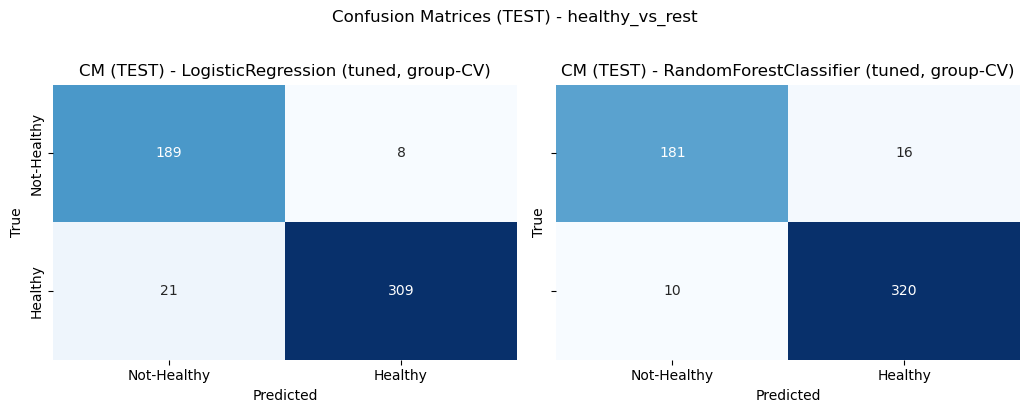

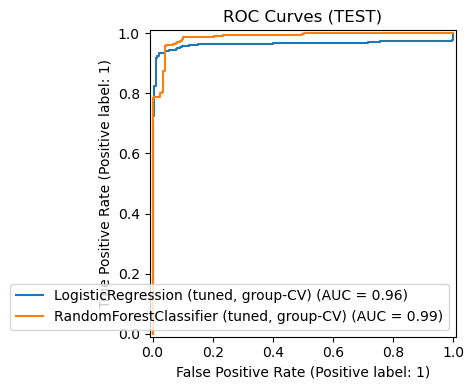

In [62]:
# Confusion matrices (TEST)
model_names = list(results.keys())
fig, axes = plt.subplots(1, len(model_names), figsize=(5.2 * len(model_names), 4.0), sharey=True)
if len(model_names) == 1:
    axes = [axes]
for ax, model_name in zip(axes, model_names):
    y_hat = results[model_name]["y_test_pred"]
    sns.heatmap(confusion_matrix(y_test, y_hat), annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f"CM (TEST) - {model_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.suptitle(f"Confusion Matrices (TEST) - {BINARY_SCHEME}", y=1.02)
plt.tight_layout()
plt.show()

# ROC curves (TEST)
fig, ax = plt.subplots(figsize=(5.2, 4.0))
for model_name in model_names:
    RocCurveDisplay.from_predictions(y_test, results[model_name]["y_test_proba"], name=model_name, ax=ax)
ax.set_title("ROC Curves (TEST)")
plt.tight_layout()
plt.show()

## 6) Overfitting check
A simple, practical check is to compare **train vs test** performance. Large gaps suggest overfitting.

In [63]:
rows = []
for model_name, r in results.items():
    train_acc = accuracy_score(y_train, r["y_train_pred"])
    test_acc = accuracy_score(y_test, r["y_test_pred"])
    train_macro_f1 = f1_score(y_train, r["y_train_pred"], average="macro")
    test_macro_f1 = f1_score(y_test, r["y_test_pred"], average="macro")
    rows.append({
        "model": model_name,
        "train_accuracy": float(train_acc),
        "test_accuracy": float(test_acc),
        "accuracy_gap": float(train_acc - test_acc),
        "train_macro_f1": float(train_macro_f1),
        "test_macro_f1": float(test_macro_f1),
        "macro_f1_gap": float(train_macro_f1 - test_macro_f1),
    })

pretty_header("Overfitting summary (train vs test)")
print("Target scheme:", BINARY_SCHEME, "| Positive class:", POS_LABEL_MEANING)
summary_df = pd.DataFrame(rows).sort_values(by="test_macro_f1", ascending=False)
print(summary_df.round(4).to_string(index=False))


Overfitting summary (train vs test)
Target scheme: healthy_vs_rest | Positive class: Healthy (SOH ≥ 0.80)
                                   model  train_accuracy  test_accuracy  accuracy_gap  train_macro_f1  test_macro_f1  macro_f1_gap
RandomForestClassifier (tuned, group-CV)          0.9930         0.9507        0.0424          0.9893          0.947        0.0423
    LogisticRegression (tuned, group-CV)          0.9651         0.9450        0.0201          0.9486          0.942        0.0067


## 7) Optional: Group-based cross-validation (battery_id)
Group-based CV is a stronger generalization check than a single train/test split because each fold holds out **entire batteries**.
When enabled, we compute out-of-fold predictions (OOF) and summarize performance across folds using `battery_id` as the grouping variable.

In [64]:
RUN_GROUP_CV = False
if RUN_GROUP_CV:
    from sklearn.model_selection import GroupKFold, cross_val_predict
    groups = df["battery_id"].to_numpy()
    n_splits = min(5, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    for model_name, model in models.items():
        y_oof_pred = cross_val_predict(model, X, y, cv=gkf, groups=groups, method="predict", n_jobs=-1)
        y_oof_proba = cross_val_predict(model, X, y, cv=gkf, groups=groups, method="predict_proba", n_jobs=-1)[:, 1]
        summarize(f"MODEL: {model_name} | SPLIT: GROUP-CV (n_splits={n_splits})", y, y_oof_pred, y_proba_1=y_oof_proba)

## 8) RUL classification (Remaining Useful Life)

We build a **binary (2-class) classification target for RUL** and train the same two model families:
- Logistic Regression (scaled)
- Random Forest

### Target definition (binary)
- If a numeric RUL column exists, we use it directly.
- Otherwise, we compute RUL as **remaining cycles**: `max_cycle_per_battery - cycle` (requires a cycle index column).
- We discretize numeric RUL into **2 classes** using a threshold computed **on the training split only** (to avoid using information from the test distribution):
  - **Short RUL (label = 1)**: lowest-third of training RUL (≤ train quantile $q_{1/3}$)
  - **Not-Short RUL (label = 0)**: everything above that threshold

### Leakage control
- Train/test split remains **battery_id-based** (cycles from a single battery never span both splits).

In [65]:
# -------------------- RUL target setup --------------------
# Config
from typing import Optional, Sequence

# Use 2 classes (binary), similar to the SOH section.
# - "binary_short_vs_rest": Short RUL (lowest-third of TRAIN RUL) vs Not-Short
# - "tertiles": 3 classes (Short/Medium/Long) for an optional multi-class setting
RUL_CLASS_SCHEME = "binary_short_vs_rest"  # options: "binary_short_vs_rest", "tertiles"

RUL_COL_CANDIDATES = [
    "RUL",
    "rul",
    "remaining_useful_life",
    "RemainingUsefulLife",
    "remaining_life",
    "cycles_to_eol",
    "Cycles_to_EOL",
    "rul_cycles",
]
CYCLE_COL_CANDIDATES = [
    "cycle",
    "Cycle",
    "cycle_index",
    "cycle_number",
    "cycle_id",
]

SELECTED_FEATURES_RUL_PATH = OUT_DIR / "selected_features_rul.csv"


def _first_existing_col(df_: pd.DataFrame, candidates: Sequence[str]) -> Optional[str]:
    for c in candidates:
        if c in df_.columns:
            return c
    # case-insensitive fallback
    lower_map = {c.lower(): c for c in df_.columns}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None


# Ensure we have a battery split (reuse the same split used above if it exists)
if "train_mask" not in globals() or "test_mask" not in globals():
    unique_batts = df["battery_id"].unique()
    train_batts, test_batts = train_test_split(unique_batts, test_size=0.2, random_state=42)
    train_mask = df["battery_id"].isin(train_batts)
    test_mask = ~train_mask

rul_col = _first_existing_col(df, RUL_COL_CANDIDATES)
cycle_col = _first_existing_col(df, CYCLE_COL_CANDIDATES)

if rul_col is not None:
    rul_numeric = pd.to_numeric(df[rul_col], errors="coerce")
    rul_source = f"column: {rul_col}"
else:
    if cycle_col is None:
        raise ValueError(
            "No RUL column found and could not compute it because no cycle index column was found. "
            f"Tried RUL candidates: {RUL_COL_CANDIDATES} and cycle candidates: {CYCLE_COL_CANDIDATES}."
        )
    cycle_vals = pd.to_numeric(df[cycle_col], errors="coerce")
    max_cycle = df.groupby("battery_id")[cycle_col].transform("max")
    rul_numeric = pd.to_numeric(max_cycle, errors="coerce") - cycle_vals
    rul_source = f"computed: group_max({cycle_col}) - {cycle_col}"

# Clean numeric RUL
rul_numeric = rul_numeric.replace([np.inf, -np.inf], np.nan)
if rul_numeric.isna().any():
    rul_numeric = rul_numeric.fillna(rul_numeric.median())

rul_numeric = rul_numeric.clip(lower=0)

# Discretize using TRAIN ONLY distribution
rul_train = rul_numeric.loc[train_mask].to_numpy()

if RUL_CLASS_SCHEME == "tertiles":
    q1, q2 = np.quantile(rul_train, [1 / 3, 2 / 3])

    def rul_to_class(v: float) -> int:
        if v <= q1:
            return 0  # short
        if v <= q2:
            return 1  # medium
        return 2  # long

    CLASS_NAMES_RUL = ["Short RUL", "Medium RUL", "Long RUL"]
    print("RUL class thresholds (train quantiles):", {"q1": float(q1), "q2": float(q2)})

elif RUL_CLASS_SCHEME == "binary_short_vs_rest":
    q1 = float(np.quantile(rul_train, 1 / 3))

    def rul_to_class(v: float) -> int:
        # label=1 => Short (consistent with the positive-class convention used in SOH)
        return 1 if v <= q1 else 0

    CLASS_NAMES_RUL = ["Not-Short RUL", "Short RUL"]
    print("RUL binary threshold (train q1):", q1)

else:
    raise ValueError(f"Unknown RUL_CLASS_SCHEME: {RUL_CLASS_SCHEME}")

# Build y_rul
y_rul = rul_numeric.astype(float).apply(rul_to_class).astype(int)

print("RUL source:", rul_source)
print("RUL numeric summary:")
display(rul_numeric.describe())
print("RUL class distribution:")
display(y_rul.value_counts().sort_index())

# -------------------- RUL features --------------------
# Prefer selected RUL features if available
feature_names_rul = None
if SELECTED_FEATURES_RUL_PATH.exists():
    sel_rul = pd.read_csv(SELECTED_FEATURES_RUL_PATH)
    if "feature" in sel_rul.columns:
        requested = sel_rul["feature"].astype(str).tolist()
        found = [f for f in requested if f in df.columns]
        missing_feats = sorted(set(requested) - set(found))
        feature_names_rul = found

        print(f"Selected RUL features file: {SELECTED_FEATURES_RUL_PATH.name}")
        print(f"- Requested: {len(requested)}")
        print(f"- Found in dataset: {len(found)}")
        print(f"- Missing from dataset: {len(missing_feats)}")
        if len(missing_feats) and len(missing_feats) <= 15:
            print("  Missing examples:", missing_feats)
        if len(found) == 0:
            print("No selected RUL features matched columns; falling back to numeric feature selection.")
            feature_names_rul = None

if feature_names_rul:
    X_rul = df[feature_names_rul].copy()
else:
    # fallback: numeric features excluding obvious identifiers + targets
    drop_cols = {
        "battery_id",
        "SOH",
        "SOH_bin",
        "SOH_class",
    }
    if rul_col is not None:
        drop_cols.add(rul_col)
    if cycle_col is not None:
        drop_cols.add(cycle_col)

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    use_cols = [c for c in numeric_cols if c not in drop_cols]
    X_rul = df[use_cols].copy()
    print(f"Using {len(use_cols)} numeric feature columns for RUL (fallback mode)")

# Basic cleaning
X_rul = X_rul.select_dtypes(include=[np.number])
X_rul = X_rul.replace([np.inf, -np.inf], np.nan)
X_rul = X_rul.fillna(X_rul.median(numeric_only=True))

# Train/test split (battery-level, reuse masks)
X_rul_train = X_rul.loc[train_mask].reset_index(drop=True)
X_rul_test = X_rul.loc[test_mask].reset_index(drop=True)
y_rul_train = y_rul.loc[train_mask].reset_index(drop=True)
y_rul_test = y_rul.loc[test_mask].reset_index(drop=True)
groups_rul_train = df.loc[train_mask, "battery_id"].to_numpy()

print("RUL X_train shape:", X_rul_train.shape, "| X_test shape:", X_rul_test.shape)
print("Train class counts:")
display(y_rul_train.value_counts().sort_index())
print("Test class counts:")
display(y_rul_test.value_counts().sort_index())


RUL binary threshold (train q1): 78.0
RUL source: column: RUL
RUL numeric summary:


count    2247.000000
mean      183.028927
std       151.898046
min         0.000000
25%        60.000000
50%       146.000000
75%       263.000000
max       612.000000
Name: RUL, dtype: float64

RUL class distribution:


RUL
0    1520
1     727
Name: count, dtype: int64

Selected RUL features file: selected_features_rul.csv
- Requested: 25
- Found in dataset: 25
- Missing from dataset: 0
RUL X_train shape: (1720, 25) | X_test shape: (527, 25)
Train class counts:


RUL
0    1142
1     578
Name: count, dtype: int64

Test class counts:


RUL
0    378
1    149
Name: count, dtype: int64

## 8b) Leakage-safe tuning for RUL (GroupKFold by battery_id)

To avoid overly optimistic validation scores, we tune hyperparameters **only on the training split** using **GroupKFold grouped by `battery_id`**. This ensures:

- **No battery** appears in both train and validation folds during tuning (prevents leakage across correlated cycles).
- We optimize for **macro-F1** (robust under imbalance and consistent if the target is later extended beyond binary).
- After tuning, we **refit the best model on the full training split** and evaluate once on the held-out test split.

Controls:
- `RUN_TUNING_RUL=True` runs the tuning searches.
- `RUN_TUNING_RUL=False` skips tuning and fits baseline models (faster).

In [66]:
# -------------------- RUL classification models + leakage-safe tuning --------------------
# We tune ONLY on the TRAIN split and we do it with GroupKFold grouped by battery_id.
# This prevents leakage because cycles from the same battery are highly correlated.
#

# Output of this cell:
# - `models_rul`: dict of the final (baseline or tuned) fitted estimators
# - `results_rul`: dict with train/test predictions
# - printed train/test metrics + an overfitting-gap table

from sklearn.multiclass import OneVsRestClassifier

# Toggle: set False for a quick baseline run
RUN_TUNING_RUL = True

# -------------------- CV setup (TRAIN only) --------------------
# GroupKFold requires at least 2 unique groups
n_unique_groups_rul = len(np.unique(groups_rul_train))
n_splits_rul = min(5, n_unique_groups_rul)
can_group_cv = n_splits_rul >= 2

if RUN_TUNING_RUL and not can_group_cv:
    print(
        "[RUL] Not enough unique batteries in the training split for GroupKFold tuning "
        f"(unique={n_unique_groups_rul}). Falling back to baseline models."
    )

# -------------------- Model selection --------------------
# We optimize macro-F1 because it is robust when class distribution is not perfectly balanced.
if RUN_TUNING_RUL and can_group_cv:
    gkf_rul = GroupKFold(n_splits=n_splits_rul)

    # ---- 1) Tune Logistic Regression (OvR) ----
    # Pipeline = scaling + OvR(LogReg). Grid over penalty and C.
    logreg_rul_pipe = Pipeline(steps=[
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        (
            "clf",
            OneVsRestClassifier(
                LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    solver="liblinear",
                    random_state=42,
                )
            ),
        ),
    ])

    logreg_rul_param_grid = {
        "clf__estimator__penalty": ["l1", "l2"],
        "clf__estimator__C": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
    }

    logreg_rul_search = GridSearchCV(
        estimator=logreg_rul_pipe,
        param_grid=logreg_rul_param_grid,
        scoring="f1_macro",
        cv=gkf_rul,
        n_jobs=-1,
        refit=True,
    )

    logreg_rul_search.fit(X_rul_train, y_rul_train, groups=groups_rul_train)

    print("\n[RUL] Logistic Regression tuning (GroupKFold on train)")
    print("n_splits:", n_splits_rul)
    print("Best CV macro-F1:", round(float(logreg_rul_search.best_score_), 4))
    print("Best params:", logreg_rul_search.best_params_)

    # ---- 2) Tune Random Forest (regularization-focused) ----
    # Earlier results showed a large train→test gap for Random Forest in the RUL task.
    # The search space below biases toward simpler trees and stronger regularization:
    # - shallower `max_depth`
    # - larger `min_samples_leaf` / `min_samples_split`
    # - optional row subsampling via `max_samples` (bootstrap must be True)
    rf_rul_base = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample",
        bootstrap=True,
    )

    rf_rul_param_distributions = {
        "n_estimators": [300, 500, 800],
        "max_depth": [3, 5, 8, 10, 12, None],
        "min_samples_split": [10, 20, 50, 100],
        "min_samples_leaf": [5, 10, 20, 50],
        "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
        "max_samples": [0.6, 0.8, 1.0],
    }

    rf_rul_search = RandomizedSearchCV(
        estimator=rf_rul_base,
        param_distributions=rf_rul_param_distributions,
        n_iter=25,
        scoring="f1_macro",
        cv=gkf_rul,
        n_jobs=-1,
        random_state=42,
        refit=True,
    )

    rf_rul_search.fit(X_rul_train, y_rul_train, groups=groups_rul_train)

    print("\n[RUL] Random Forest tuning (GroupKFold on train)")
    print("n_splits:", n_splits_rul)
    print("Best CV macro-F1:", round(float(rf_rul_search.best_score_), 4))
    print("Best params:", rf_rul_search.best_params_)

    models_rul = {
        "LogisticRegression (tuned, group-CV)": logreg_rul_search.best_estimator_,
        "RandomForestClassifier (tuned, group-CV)": rf_rul_search.best_estimator_,
    }

else:
    # Baseline (no tuning)
    models_rul = {
        "LogisticRegression (scaled, OvR)": Pipeline(steps=[
            ("scaler", StandardScaler(with_mean=True, with_std=True)),
            (
                "clf",
                OneVsRestClassifier(
                    LogisticRegression(
                        max_iter=5000,
                        class_weight="balanced",
                        solver="liblinear",
                        random_state=42,
                        C=1.0,
                    )
                ),
            ),
        ]),
        "RandomForestClassifier (regularized)": RandomForestClassifier(
            n_estimators=600,
            max_depth=14,
            min_samples_split=10,
            min_samples_leaf=4,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
            bootstrap=True,
            max_samples=0.8,
        ),
    }

# -------------------- Fit + predict --------------------
results_rul = {}
for name, model in models_rul.items():
    model.fit(X_rul_train, y_rul_train)
    results_rul[name] = {
        "model": model,
        "y_train_pred": model.predict(X_rul_train),
        "y_test_pred": model.predict(X_rul_test),
    }

# -------------------- Evaluation helpers --------------------
# Keep confusion-matrix label ordering stable even if a class is rare.

def cm_df_rul(y_true, y_hat, labels):
    label_ids = list(range(len(labels)))
    cm = confusion_matrix(y_true, y_hat, labels=label_ids)
    return pd.DataFrame(
        cm,
        index=[f"True: {c}" for c in labels],
        columns=[f"Pred: {c}" for c in labels],
    )


def summarize_rul(name: str, y_true, y_hat) -> dict:
    acc = accuracy_score(y_true, y_hat)
    bal_acc = balanced_accuracy_score(y_true, y_hat)
    macro_f1 = f1_score(y_true, y_hat, average="macro")

    pretty_header(name)
    print("Samples:", len(y_true))
    print(
        "Accuracy:",
        round(float(acc), 4),
        "| Balanced accuracy:",
        round(float(bal_acc), 4),
        "| Macro F1:",
        round(float(macro_f1), 4),
    )
    print("\nConfusion matrix:")
    print(cm_df_rul(y_true, y_hat, CLASS_NAMES_RUL))
    print("\nClassification report:")
    print(classification_report(y_true, y_hat, target_names=CLASS_NAMES_RUL, digits=4))
    return {"accuracy": float(acc), "balanced_accuracy": float(bal_acc), "macro_f1": float(macro_f1)}


# -------------------- Train/test reporting --------------------
metrics_rows = []
for model_name, r in results_rul.items():
    m_tr = summarize_rul(
        f"RUL | MODEL: {model_name} | SPLIT: TRAIN",
        y_rul_train,
        r["y_train_pred"],
    )
    m_te = summarize_rul(
        f"RUL | MODEL: {model_name} | SPLIT: TEST",
        y_rul_test,
        r["y_test_pred"],
    )
    metrics_rows.append(
        {
            "model": model_name,
            "train_accuracy": m_tr["accuracy"],
            "test_accuracy": m_te["accuracy"],
            "accuracy_gap": m_tr["accuracy"] - m_te["accuracy"],
            "train_macro_f1": m_tr["macro_f1"],
            "test_macro_f1": m_te["macro_f1"],
            "macro_f1_gap": m_tr["macro_f1"] - m_te["macro_f1"],
        }
    )

pretty_header("RUL overfitting summary (train vs test)")
print("RUL scheme:", RUL_CLASS_SCHEME, "| labels:", CLASS_NAMES_RUL)
summary_rul_df = pd.DataFrame(metrics_rows).sort_values(by="test_macro_f1", ascending=False)
print(summary_rul_df.round(4).to_string(index=False))



[RUL] Logistic Regression tuning (GroupKFold on train)
n_splits: 5
Best CV macro-F1: 0.6156
Best params: {'clf__estimator__C': 0.01, 'clf__estimator__penalty': 'l2'}

[RUL] Random Forest tuning (GroupKFold on train)
n_splits: 5
Best CV macro-F1: 0.7261
Best params: {'n_estimators': 800, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_samples': 1.0, 'max_features': 'log2', 'max_depth': 8}

RUL | MODEL: LogisticRegression (tuned, group-CV) | SPLIT: TRAIN
Samples: 1720
Accuracy: 0.7547 | Balanced accuracy: 0.7499 | Macro F1: 0.7368

Confusion matrix:
                     Pred: Not-Short RUL  Pred: Short RUL
True: Not-Short RUL                  873              269
True: Short RUL                      153              425

Classification report:
               precision    recall  f1-score   support

Not-Short RUL     0.8509    0.7644    0.8054      1142
    Short RUL     0.6124    0.7353    0.6682       578

     accuracy                         0.7547      1720
    macro avg     0.

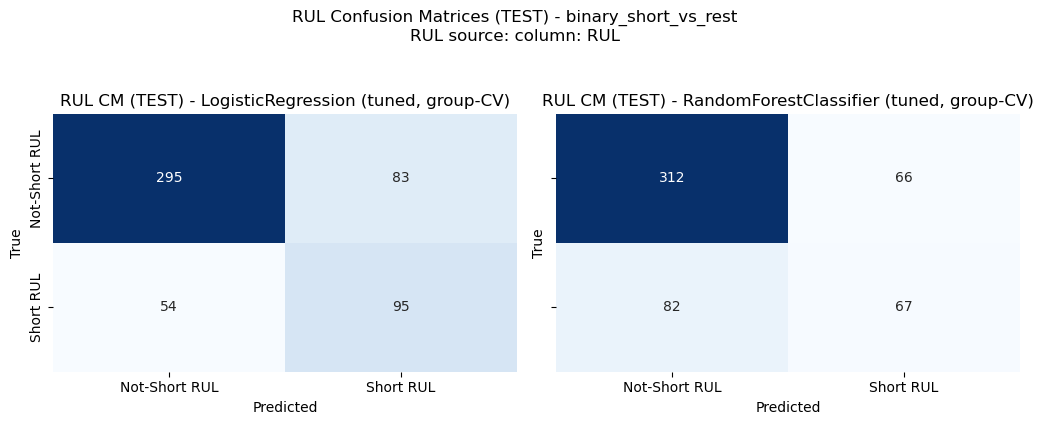

In [67]:
# -------------------- RUL plots + optional group-CV --------------------
# Confusion matrices (TEST)
model_names_rul = list(results_rul.keys())
fig, axes = plt.subplots(1, len(model_names_rul), figsize=(5.2 * len(model_names_rul), 4.0), sharey=True)
if len(model_names_rul) == 1:
    axes = [axes]

label_ids_rul = list(range(len(CLASS_NAMES_RUL)))

for ax, model_name in zip(axes, model_names_rul):
    y_hat = results_rul[model_name]["y_test_pred"]
    cm = confusion_matrix(y_rul_test, y_hat, labels=label_ids_rul)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=CLASS_NAMES_RUL,
        yticklabels=CLASS_NAMES_RUL,
        ax=ax,
    )
    ax.set_title(f"RUL CM (TEST) - {model_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle(f"RUL Confusion Matrices (TEST) - {RUL_CLASS_SCHEME}\nRUL source: {rul_source}", y=1.05)
plt.tight_layout()
plt.show()

# Optional: GroupKFold cross-validation (battery_id)
RUN_GROUP_CV_RUL = False
if RUN_GROUP_CV_RUL:
    from sklearn.model_selection import cross_val_predict

    groups_all = df["battery_id"].to_numpy()
    n_splits_rul = min(5, len(np.unique(groups_all)))
    if n_splits_rul < 2:
        raise ValueError("Not enough unique batteries for GroupKFold CV")

    gkf_rul = GroupKFold(n_splits=n_splits_rul)

    pretty_header(f"RUL GroupKFold CV (n_splits={n_splits_rul})")
    for model_name, model in models_rul.items():
        y_oof_pred = cross_val_predict(
            model,
            X_rul,
            y_rul,
            cv=gkf_rul,
            groups=groups_all,
            method="predict",
            n_jobs=-1,
        )
        summarize_rul(f"RUL | MODEL: {model_name} | SPLIT: GROUP-CV", y_rul, y_oof_pred)


## 9) Conclusion and key insights

### Summary
- We built leakage-safe binary classifiers for **SOH** and **RUL** using an explicit **battery_id hold-out split**.
- We used selected feature lists (when available) to keep the modeling inputs aligned with prior feature selection.
- We tuned hyperparameters using **GroupKFold grouped by battery_id** on the training split only, then evaluated once on the held-out test split.

### Key insights from this notebook
- **Leakage control matters**: splitting and tuning by `battery_id` prevents cycles from the same battery from inflating validation scores.
- **Binary RUL definition**: the **Short vs Not-Short** threshold is computed from the **training** RUL distribution ($q_{1/3}$), then applied to both train and test.
- **Generalization vs overfitting**: the train→test gap table provides a quick signal of whether a model is overfitting (large gap) or generalizing (small gap).
- **Model behavior differs by task**: Logistic Regression often yields stable generalization, while Random Forest can overfit unless regularized (shallower trees, larger leaf sizes, subsampling).

### Suggested follow-ups (optional extensions within the same leakage-safe setup)
- Add ROC AUC and ROC curves for the RUL task (binary) using `predict_proba`.
- Compare models using GroupKFold out-of-fold metrics as the primary score (in addition to the hold-out test split).
- Explore alternative binary thresholds for RUL (e.g., $q_{0.25}$ or a domain-driven cycle cutoff) and compare macro-F1 / balanced accuracy.

## 10) Save trained models for inference

In [ ]:
import joblib
from pathlib import Path

# Create models directory
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Save SOH classification models
print("Saving SOH classification models...")
for model_name, result_dict in results.items():
    model = result_dict["model"]
    safe_name = model_name.replace(" ", "_").replace("(", "").replace(")", "").replace(",", "")
    model_path = models_dir / f"soh_classifier_{safe_name}.joblib"
    joblib.dump(model, model_path)
    print(f"  Saved: {model_path}")

# Save SOH feature names
soh_features_path = models_dir / "soh_features.joblib"
joblib.dump(feature_names if feature_names else X.columns.tolist(), soh_features_path)
print(f"  Saved: {soh_features_path}")

# Save SOH metadata
soh_metadata = {
    "binary_scheme": BINARY_SCHEME,
    "class_names": CLASS_NAMES,
    "pos_label_meaning": POS_LABEL_MEANING,
}
metadata_path = models_dir / "soh_metadata.joblib"
joblib.dump(soh_metadata, metadata_path)
print(f"  Saved: {metadata_path}")

# Save RUL classification models
print("\nSaving RUL classification models...")
for model_name, result_dict in results_rul.items():
    model = result_dict["model"]
    safe_name = model_name.replace(" ", "_").replace("(", "").replace(")", "").replace(",", "")
    model_path = models_dir / f"rul_classifier_{safe_name}.joblib"
    joblib.dump(model, model_path)
    print(f"  Saved: {model_path}")

# Save RUL feature names
rul_features_path = models_dir / "rul_features.joblib"
joblib.dump(feature_names_rul if feature_names_rul else X_rul.columns.tolist(), rul_features_path)
print(f"  Saved: {rul_features_path}")

# Save RUL metadata
rul_metadata = {
    "class_scheme": RUL_CLASS_SCHEME,
    "class_names": CLASS_NAMES_RUL,
    "rul_source": rul_source,
}
rul_metadata_path = models_dir / "rul_metadata.joblib"
joblib.dump(rul_metadata, rul_metadata_path)
print(f"  Saved: {rul_metadata_path}")

print("\nAll models saved successfully to 'models/' directory.")